# Évaluation de la régression logistique

CSI4506 Introduction à l’intelligence artificielle

Marcel Turcotte (École de génie électrique et d’informatique, Université
d’Ottawa)  
2026-09-24

Ce carnet reprend la mise en œuvre de la régression logistique du cours
6 afin de pouvoir être exécuté indépendamment. Le cours 7 répète cette
mise en œuvre sur une diapositive repliée. Le présent carnet approfondit
les rapports de classification, les matrices de confusion, les courbes
ROC, l’AUROC et les compromis liés au seuil de classification.

# Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_breast_cancer, make_blobs
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Mise en œuvre de la régression logistique

La classe ajoute l’ordonnée à l’origine et suit les mêmes équations
d’entropie croisée binaire et de descente de gradient par lot qu’au
cours 6.

In [2]:
import numpy as np

class LogisticRegression:

    """
    Régression logistique binaire entraînée par descente de gradient par lot.

    Paramètres
    ----------
    learning_rate : float, default=0.1
        Pas de la descente de gradient.
    max_iter : int, default=1000
        Nombre d'itérations de la descente de gradient.
    Remarques
    ---------
    - Cette mise en œuvre attend des étiquettes binaires {0, 1}.
    - L'ordonnée à l'origine est ajoutée pendant `fit`.
    - Par souci de simplicité, il n'y a ni régularisation ni arrêt précoce.
    """

    def __init__(
        self,
        learning_rate: float = 0.1,
        max_iter: int = 1000,
    ):
        if learning_rate <= 0:
            raise ValueError("learning_rate doit être positif.")
        if max_iter <= 0:
            raise ValueError("max_iter doit être positif.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter

        # Attributs définis après l'ajustement
        self._theta = None
        self._loss_history = None
        self._n_features = None
        self._fitted = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """Ajuster les paramètres du modèle par descente de gradient."""
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                "X et y doivent contenir le même nombre d'exemples."
            )
        self._check_binary_labels(y)

        n_examples, n_features = X.shape
        self._n_features = n_features
        Xb = self._add_intercept(X)

        # Une initialisation à zéro suffit puisque l'objectif est convexe.
        self._theta = np.zeros(n_features + 1, dtype=float)
        self._loss_history = []

        for _ in range(self.max_iter):
            probabilities = self._sigmoid(Xb @ self._theta)
            gradient = (Xb.T @ (probabilities - y)) / n_examples
            self._theta -= self.learning_rate * gradient

            updated_probabilities = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(
                self._bce_loss(updated_probabilities, y)
            )

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Retourner les probabilités prédites de la classe positive."""
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)

        Xb = self._add_intercept(X)
        return self._sigmoid(Xb @ self._theta)

    def predict(
        self,
        X: np.ndarray,
        threshold: float = 0.5,
    ) -> np.ndarray:
        """Retourner les classes prédites selon un seuil de probabilité."""
        if not 0 <= threshold <= 1:
            raise ValueError("threshold doit être compris entre 0 et 1.")
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Retourner l'ordonnée à l'origine ajustée."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Retourner une copie des coefficients ajustés."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list:
        """Retourner une copie des pertes recueillies pendant l'ajustement."""
        self._ensure_fitted()
        return list(self._loss_history)

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Calculer la sigmoïde sans débordement numérique."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(probabilities: np.ndarray, y: np.ndarray) -> float:
        probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
        return float(
            -np.mean(
                y * np.log(probabilities)
                + (1 - y) * np.log(1 - probabilities)
            )
        )

    @staticmethod
    def _as_2d_array(X, name="X") -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            message = (
                f"{name} doit être un tableau 2D de forme "
                "(n_samples, n_features)."
            )
            raise ValueError(message)
        return X

    @staticmethod
    def _as_1d_array(y, name="y") -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            message = f"{name} doit avoir la forme (n_samples,)."
            raise ValueError(message)
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError(
                "y doit contenir les deux étiquettes binaires 0 et 1."
            )

    @staticmethod
    def _add_intercept(X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError(
                "Appelez fit(X, y) avant d'utiliser le modèle ajusté."
            )

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            message = (
                f"X contient {X.shape[1]} attributs; "
                f"{self._n_features} étaient attendus."
            )
            raise ValueError(message)

# Exemple d’évaluation synthétique

Nous commençons par un jeu de données à deux attributs afin d’évaluer
les probabilités prédites sans introduire un domaine d’application
complexe.

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=5,
    random_state=42,
)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Entraînement et prédictions à seuil fixe

In [4]:
model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Rapport de classification :\n")
print(classification_report(y_test, y_pred))

Rapport de classification :

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       150
           1       0.86      0.84      0.85       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


# Mise en œuvre de ROC et de l’AUROC

In [5]:
def compute_roc_curve(y_true, y_scores):
    """Calculer les points ROC en faisant varier le seuil de classification."""
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    thresholds = np.r_[np.inf, np.sort(np.unique(y_scores))[::-1]]

    tpr_list, fpr_list = [], []
    for threshold in thresholds:
        # Classer positif si la probabilité prédite atteint le seuil
        y_pred = (y_scores >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr_list.append(tp / (tp + fn))
        fpr_list.append(fp / (fp + tn))

    return np.array(fpr_list), np.array(tpr_list), thresholds

## Calcul de l’AUROC

In [6]:
def compute_auroc(fpr, tpr):
    """
    Calculer l'aire sous la courbe ROC par la règle des trapèzes.

    fpr : tableau des taux de faux positifs
    tpr : tableau des taux de vrais positifs
    """
    return np.trapezoid(tpr, fpr)

L’AUROC mesure la qualité du classement. Elle correspond à la
probabilité qu’un exemple positif choisi au hasard reçoive un score
supérieur à celui d’un exemple négatif choisi au hasard, sous réserve du
traitement des égalités. Un classement aléatoire a une AUROC attendue de
0,5, tandis qu’un classement systématiquement inversé peut produire une
valeur inférieure à 0,5.

## Courbe ROC

AUROC calculée manuellement : 0.938
AUROC de scikit-learn :      0.938

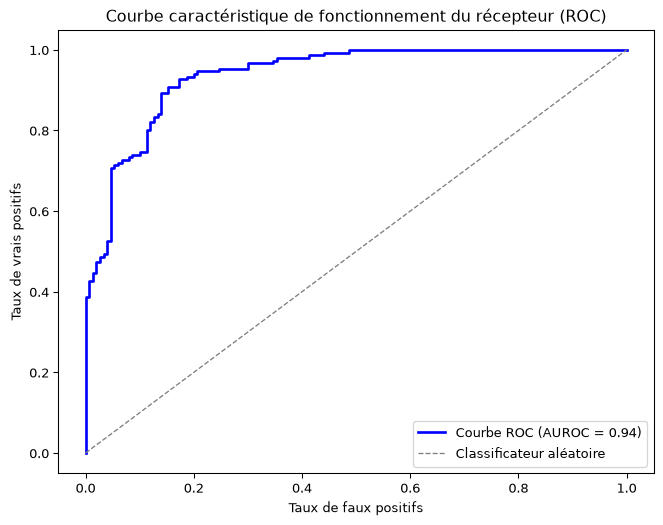

In [7]:
# Calculer les probabilités prédites de la classe positive sur l'ensemble de test
y_probs = model.predict_proba(X_test)

# Calculer la courbe ROC (TFP et TVP pour chaque seuil)
fpr, tpr, thresholds = compute_roc_curve(y_test, y_probs)
auroc_value = compute_auroc(fpr, tpr)
sklearn_auroc = roc_auc_score(y_test, y_probs)

print(f"AUROC calculée manuellement : {auroc_value:.3f}")
print(f"AUROC de scikit-learn :      {sklearn_auroc:.3f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="blue",
    lw=2,
    label=f"Courbe ROC (AUROC = {auroc_value:.2f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    lw=1,
    linestyle="--",
    label="Classificateur aléatoire",
)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe caractéristique de fonctionnement du récepteur (ROC)")
plt.legend(loc="lower right")
plt.show()

# Jeu de données sur le cancer du sein

Cet exemple utilise le jeu de données sur le cancer du sein de
scikit-learn. Dans ce jeu de données, l’étiquette 0 désigne une tumeur
maligne et l’étiquette 1, une tumeur bénigne.

Forme du jeu de données : (569, 30), étiquettes : [212 357]
Noms des attributs (les 5 premiers) : ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Rapport de classification :
              precision    recall  f1-score   support

     maligne       0.98      0.98      0.98        42
     bénigne       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


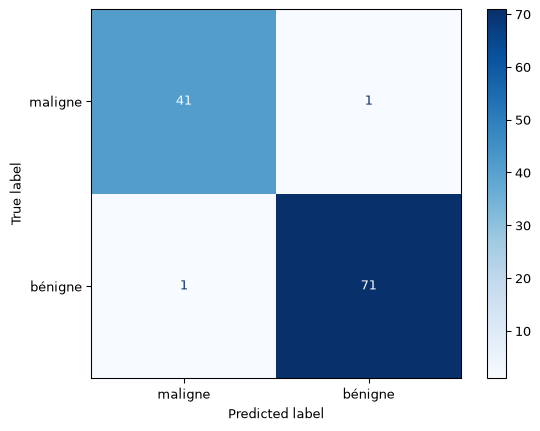

In [8]:
# Objectif : classer les tumeurs comme malignes (0) ou bénignes (1)
# Jeu de données : sklearn.datasets.load_breast_cancer
# Modèle : régression logistique de scikit-learn

# 1. Charger le jeu de données
data = load_breast_cancer()
X, y = data.data, data.target
target_names_fr = np.array(["maligne", "bénigne"])
print(f"Forme du jeu de données : {X.shape}, étiquettes : {np.bincount(y)}")
print("Noms des attributs (les 5 premiers) :", data.feature_names[:5])

# 2. Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Mettre les attributs à l'échelle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraîner la régression logistique
clf = SKLogisticRegression(max_iter=5000, random_state=42)
clf.fit(X_train_scaled, y_train)

# 5. Évaluer
y_pred = clf.predict(X_test_scaled)

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names_fr,
        zero_division=0,
    )
)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names_fr,
)
disp.plot(cmap="Blues")
plt.show()

# Jeu de données sur le diabète des Indiennes Pima

Ce jeu de données illustre comment le seuil de classification détermine
le compromis entre le taux de vrais positifs et le taux de faux
positifs. Les taux indiqués sont calculés à partir de la division
actuelle en ensembles d’entraînement et de test plutôt que fixés dans le
texte.

Forme du jeu de données : (768, 8), étiquettes : [500 268]
TVP le plus proche : 0.851
TFP correspondant :  0.312
Seuil :              0.271

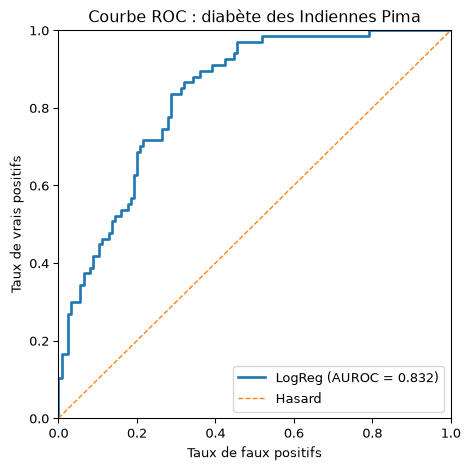

In [9]:
# 1) Charger le jeu de données Pima au moyen de son identifiant OpenML stable.
dataset = fetch_openml(data_id=37, as_frame=True)
X = dataset.data
y = dataset.target.astype(str).str.lower().map(
    {
        "tested_negative": 0,
        "tested_positive": 1,
        "0": 0,
        "1": 1,
    }
)

if y.isna().any():
    raise ValueError("Les étiquettes cibles d'OpenML n'ont pas été reconnues.")

y = y.astype(int)
print(f"Forme du jeu de données : {X.shape}, étiquettes : {np.bincount(y)}")

# 2) Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Mettre les attributs à l'échelle
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 4) Entraîner la régression logistique
clf = SKLogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_s, y_train)

# 5) Courbe ROC et AUROC
y_score = clf.predict_proba(X_test_s)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)

# Indiquer le point de fonctionnement le plus proche du TVP cible.
target_tpr = 0.85
idx = np.argmin(np.abs(tpr - target_tpr))

print(f"TVP le plus proche : {tpr[idx]:.3f}")
print(f"TFP correspondant :  {fpr[idx]:.3f}")
print(f"Seuil :              {thresholds[idx]:.3f}")

# 6) Tracer la courbe
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f"LogReg (AUROC = {auroc:.3f})")
plt.plot([0, 1], [0, 1], lw=1, linestyle="--", label="Hasard")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC : diabète des Indiennes Pima")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()